In [ ]:
import json
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
!wget --no-check-certificate \
    https://storage.googleapis.com/learning-datasets/sarcasm.json \
    -O /tmp/sarcasm.json # dataset


--2026-09-24 03:45:53--  https://storage.googleapis.com/learning-datasets/sarcasm.json
Resolving storage.googleapis.com (storage.googleapis.com)... 209.85.200.207, 172.217.214.207, 108.177.121.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|209.85.200.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5643545 (5.4M) [application/json]
Saving to: ‘/tmp/sarcasm.json’

/tmp/sarcasm.json   100%[===================>]   5.38M  --.-KB/s    in 0.04s   

2026-09-24 03:45:54 (143 MB/s) - ‘/tmp/sarcasm.json’ saved [5643545/5643545]



In [ ]:
with open("/tmp/sarcasm.json", 'r') as f: # abrindo o arquivo
    datastore = json.load(f) # carregando os dados

sentences = [] # lista de sentenças
labels = [] # lista de labels
urls = [] # lista de urls

for item in datastore:
    # carrega os valores para cada lista
    sentences.append(item['headline'])
    labels.append(item['is_sarcastic'])
    urls.append(item['article_link'])

In [ ]:
vocab_size = 10000       # tamanho máximo do vocabulário
embedding_dim = 16       # dimensão dos embeddings
max_length = 100         # tamanho máximo das sequências
trunc_type = 'post'      # corta palavras no final
padding_type = 'post'    # adiciona preenchimento no final
oov_tok = "<OOV>"        # token para palavras desconhecidas
training_size = 20000    # quantidade de dados para treino

In [ ]:
training_sentences = sentences[0:training_size]  # sentenças para treino
testing_sentences = sentences[training_size:]    # sentenças para teste

training_labels = labels[0:training_size]        # labels para treino
testing_labels = labels[training_size:]          # labels para teste

In [ ]:
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)  # cria o tokenizador
tokenizer.fit_on_texts(training_sentences)  # aprende o vocabulário

word_index = tokenizer.word_index  # armazena o índice das palavras

training_sequences = tokenizer.texts_to_sequences(training_sentences)  # transforma treino em sequências numéricas
training_padded = pad_sequences(training_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)  # padroniza o tamanho do treino

testing_sequences = tokenizer.texts_to_sequences(testing_sentences)  # transforma teste em sequências numéricas
testing_padded = pad_sequences(testing_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)  # padroniza o tamanho do teste

In [ ]:
import numpy as np

# converte dados e labels para array
training_padded = np.array(training_padded)
training_labels = np.array(training_labels)

testing_padded = np.array(testing_padded)
testing_labels = np.array(testing_labels)

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, embedding_dim, input_length=max_length),  # transforma palavras em vetores
    tf.keras.layers.GlobalAveragePooling1D(),  # reduz os vetores para uma representação média
    tf.keras.layers.Dense(24, activation='relu'),  # camada oculta com 24 neurônios
    tf.keras.layers.Dense(1, activation='sigmoid')  # saída para classificação binária

])

# configura o treinamento do modelo
model.compile(
    loss='binary_crossentropy',  # função de perda
    optimizer='adam',            # otimizador utilizado
    metrics=['accuracy']         # métrica de avaliação
)

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
num_epochs = 30 # numero de epocas
history = model.fit(training_padded, training_labels, epochs=num_epochs, validation_data=(testing_padded, testing_labels), verbose=2)

Epoch 1/30
625/625 - 6s - 9ms/step - accuracy: 0.5684 - loss: 0.6818 - val_accuracy: 0.5910 - val_loss: 0.6754
Epoch 2/30
625/625 - 4s - 6ms/step - accuracy: 0.7075 - loss: 0.5591 - val_accuracy: 0.7156 - val_loss: 0.5079
Epoch 3/30
625/625 - 6s - 9ms/step - accuracy: 0.8205 - loss: 0.4018 - val_accuracy: 0.8249 - val_loss: 0.3964
Epoch 4/30
625/625 - 8s - 13ms/step - accuracy: 0.8530 - loss: 0.3460 - val_accuracy: 0.8232 - val_loss: 0.3844
Epoch 5/30
625/625 - 4s - 6ms/step - accuracy: 0.8670 - loss: 0.3136 - val_accuracy: 0.8228 - val_loss: 0.3844
Epoch 6/30
625/625 - 4s - 6ms/step - accuracy: 0.8823 - loss: 0.2840 - val_accuracy: 0.8445 - val_loss: 0.3553
Epoch 7/30
625/625 - 4s - 7ms/step - accuracy: 0.8943 - loss: 0.2568 - val_accuracy: 0.8456 - val_loss: 0.3508
Epoch 8/30
625/625 - 4s - 7ms/step - accuracy: 0.9008 - loss: 0.2426 - val_accuracy: 0.8554 - val_loss: 0.3418
Epoch 9/30
625/625 - 4s - 7ms/step - accuracy: 0.9097 - loss: 0.2276 - val_accuracy: 0.8439 - val_loss: 0.3564


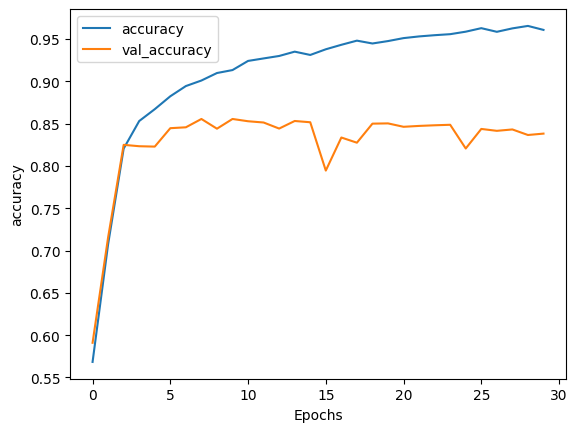

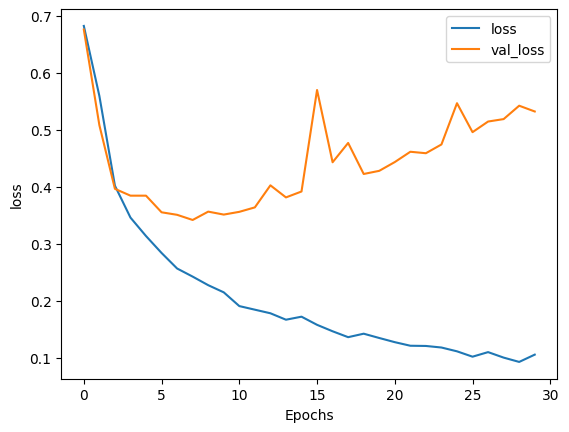

In [ ]:
import matplotlib.pyplot as plt


def plot_graphs(history, string): # cria um grafico de acuracia e val_acuracia/loss e val_loss
  plt.plot(history.history[string])
  plt.plot(history.history['val_'+string])
  plt.xlabel("Epochs")
  plt.ylabel(string)
  plt.legend([string, 'val_'+string])
  plt.show()

plot_graphs(history, "accuracy")
plot_graphs(history, "loss")

In [ ]:
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()]) # inverte o índice das palavras

def decode_sentence(text): # converte números de volta para palavras
    return ' '.join([reverse_word_index.get(i, '?') for i in text])

print(decode_sentence(training_padded[0])) # mostra a sentença decodificada
print(training_sentences[2]) # mostra a sentença original
print(labels[2]) # mostra o label da sentença

former <OOV> store clerk sues over secret 'black <OOV> for minority shoppers ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ?
mom starting to fear son's web series closest thing she will have to grandchild
1


In [ ]:
e = model.layers[0]
weights = e.get_weights()[0]
print(weights.shape) # mostra o formato

(10000, 16)


In [ ]:
import io

out_v = io.open('vecs.tsv', 'w', encoding='utf-8') # arquivo dos vetores
out_m = io.open('meta.tsv', 'w', encoding='utf-8') # arquivo das palavras
for word_num in range(1, vocab_size):
  word = reverse_word_index[word_num] # recupera a palavra pelo índice
  embeddings = weights[word_num] # recupera o vetor da palavra
  out_m.write(word + "\n") # salva a palavra
  out_v.write('\t'.join([str(x) for x in embeddings]) + "\n") # salva o vetor
# fecha os arquivos
out_v.close()
out_m.close()

In [ ]:
try:
  from google.colab import files
except ImportError: # ignora caso não esteja executando no Colab
  pass
else: # baixa o arquivo
  files.download('vecs.tsv')
  files.download('meta.tsv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
sentence = ["granny starting to fear spiders in the garden might be real", "game of thrones season finale showing this sunday night"] # frases para teste
sequences = tokenizer.texts_to_sequences(sentence) # converte as frases em sequências numéricas

padded = pad_sequences(sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type) # padroniza o tamanho das sequências
print(model.predict(padded)) # realiza previsão do modelo

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
[[0.8889757 ]
 [0.01329421]]
